[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises


Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

main author of this ipynb: https://github.com/robhau

## Fourier Series Calculus, Signal and Property Examples
FB93908026, plots graphics for fourier_series_FB93908026.tex

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
A = 1
T = 4
T_h = 2
omega = 2*np.pi/T
kmin = 0
kmax = 5
t = np.arange(-2*T, 2*T+1/100, 1/100)
k = np.arange(1, kmax+1, 1)
k2 = np.arange(kmin, kmax+1/100, 1/100)


kk1, tt1 = np.meshgrid(k, t)
kk2, tt2 = np.meshgrid(k, t)
w1 = np.cos(kk1*omega*tt1)
w2 = np.sin(kk2*omega*tt2)

In [3]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

x = 2*A*T_h*np.sinc(kk1*T_h/T)*w1
x = np.reshape(x, (t.size, k.size))
y = np.transpose(x)
x = 1/T*np.sum(x, axis=1)
x = np.real(x)+A*T_h/T

ax1.plot(t, np.zeros_like(t)+A*T_h, color='C0', label='k=0', clip_on=False)
for i in range(0, 2):
    ax1.plot(t, y[i], color='C'+str(i+1), label='k='+str(i+1), clip_on=False)
for i in range(2, kmax):
    ax1.plot(t, y[i], color='C'+str(i+2), label='k='+str(i+1), clip_on=False)
ax1.legend()
ax1.set_xticks(np.arange(-2*T, 2*T+T/2, T/2))
ax1.set_xlim(-2*T, 2*T)
ax1.grid(True)
ax1.set_xlabel('$t$')

ax2.plot(t, x, color='C0', label='$x_a(t)$', clip_on=False)
ax2.legend()
ax2.set_xticks(np.arange(-2*T, 2*T+T/2, T/2))
ax2.set_xlim(-2*T, 2*T)
ax2.grid(True)
ax2.set_xlabel('$t$')
fig.tight_layout()
fig.savefig('FB93908026_timedomain_0.pdf')

fig, ax = plt.subplots(figsize=(10, 4))

X = 2*A*T_h*np.sinc(np.append(np.array([0]), k)*T_h/T)
ax.plot(np.append(np.array([0]), k), X, ls='', marker='o',
        mec='C1', mfc='C1', clip_on=False, label='$a_k$')

X = 2*A*T_h*np.sinc(k2*T_h/T)
ax.plot(k2, X, ls=':', color='C0', clip_on=False)
ax.legend()
ax.set_xlabel('$k$')

ax.set_xticks(np.arange(0, kmax+1, 1))
ax.set_xlim(0, kmax)
ax.set_ylim(-1, 4)
ax.grid(True)
fig.tight_layout()
fig.savefig('FB93908026_frequence_0.pdf')
plt.close('all')

In [4]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

x = A*np.pi*kk1*T_h**2/T*np.sinc(kk1*T_h/(2*T))**2*w2
x = np.reshape(x, (t.size, k.size))
y = np.transpose(x)
x = 1/T*np.sum(x, axis=1)
x = np.real(x)

ax1.plot(t, np.zeros_like(t)+A*T_h, color='C0', label='k=0', clip_on=False)
for i in range(0, 2):
    ax1.plot(t, y[i], color='C'+str(i+1), label='k='+str(i+1), clip_on=False)
for i in range(2, kmax):
    ax1.plot(t, y[i], color='C'+str(i+2), label='k='+str(i+1), clip_on=False)
ax1.legend()
ax1.set_xticks(np.arange(-2*T, 2*T+T/2, T/2))
ax1.set_xlim(-2*T, 2*T)
ax1.grid(True)
ax1.set_xlabel('$t$')

ax2.plot(t, x, color='C0', label='$x_b(t)$', clip_on=False)
ax2.legend()
ax2.set_xticks(np.arange(-2*T, 2*T+T/2, T/2))
ax2.set_xlim(-2*T, 2*T)
ax2.grid(True)
ax2.set_xlabel('$t$')
fig.tight_layout()
fig.savefig('FB93908026_timedomain_1.pdf')

fig, ax = plt.subplots(figsize=(10, 4))

X = A*np.pi*np.append(np.array([0]), k)*T_h**2/T * \
    np.sinc(np.append(np.array([0]), k)*T_h/(2*T))**2
ax.plot(np.append(np.array([0]), k), X, ls='', marker='o',
        mec='C1', mfc='C1', clip_on=False, label='$b_k$')

X = A*np.pi*k2*T_h**2/T*np.sinc(k2*T_h/(2*T))**2
ax.plot(k2, X, ls=':', color='C0', clip_on=False)
ax.legend()
ax.set_xlabel('$k$')

ax.set_xticks(np.arange(0, kmax+1, 1))
ax.set_xlim(0, kmax)
ax.set_ylim(0, 3)
ax.grid(True)
fig.tight_layout()
fig.savefig('FB93908026_frequence_1.pdf')
plt.close('all')

In [5]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

x = A*T_h*np.sinc(kk1*T_h/(2*T))**2*w1
x = np.reshape(x, (t.size, k.size))
y = np.transpose(x)
x = 1/T*np.sum(x, axis=1)
x = np.real(x)

ax1.plot(t, np.zeros_like(t)+A*T_h, color='C0', label='k=0', clip_on=False)
for i in range(0, 2):
    ax1.plot(t, y[i], color='C'+str(i+1), label='k='+str(i+1), clip_on=False)
for i in range(2, kmax):
    ax1.plot(t, y[i], color='C'+str(i+2), label='k='+str(i+1), clip_on=False)
ax1.legend()
ax1.set_xticks(np.arange(-2*T, 2*T+T/2, T/2))
ax1.set_xlim(-2*T, 2*T)
ax1.grid(True)
ax1.set_xlabel('$t$')

ax2.plot(t, x, color='C0', label='$x_c(t)$', clip_on=False)
ax2.legend()
ax2.set_xticks(np.arange(-2*T, 2*T+T/2, T/2))
ax2.set_xlim(-2*T, 2*T)
ax2.grid(True)
ax2.set_xlabel('$t$')
fig.tight_layout()
fig.savefig('FB93908026_timedomain_2.pdf')

fig, ax = plt.subplots(figsize=(10, 4))

X = A*T_h*np.sinc(np.append(np.array([0]), k)*T_h/(2*T))**2
ax.plot(np.append(np.array([0]), k), X, ls='', marker='o',
        mec='C1', mfc='C1', clip_on=False, label='$a_k$')

X = A*T_h*np.sinc(k2*T_h/(2*T))**2
ax.plot(k2, X, ls=':', color='C0', clip_on=False)
ax.legend()
ax.set_xlabel('$k$')

ax.set_xticks(np.arange(0, kmax+1, 1))
ax.set_xlim(0, kmax)
ax.set_ylim(0, 2)
ax.grid(True)
fig.tight_layout()
fig.savefig('FB93908026_frequence_2.pdf')
plt.close('all')

In [6]:
A = 1
T = 4
T_h = 2
omega = 2*np.pi/T
kmin = -5
kmax = 5
a = 1/2
t = np.arange(-2*T, 2*T+1/100, 1/100)
k = np.arange(kmin, kmax+1, 1)
k2 = np.arange(kmin, kmax+1/100, 1/100)
k3 = np.arange(kmin, 0, 1)
k4 = np.arange(1, kmax+1, 1)
kk, tt = np.meshgrid(k, t)
kk3, tt3 = np.meshgrid(k3, t)
kk4, tt4 = np.meshgrid(k4, t)
w = np.exp(1j*omega*kk*tt)
w2 = np.exp(1j*omega*kk*tt*a)
w3 = np.exp(1j*omega*kk3*tt3)
w4 = np.exp(1j*omega*kk4*tt4)

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
x = A*T_h*np.sinc(kk*T_h/T)*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_ylim(-A/5, 6/5*A)
ax.set_yticks(np.arange(0, A+A/2, A/2))
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_a(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_3.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = A*T_h*np.sinc(k2*T_h/T)
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ck_ph = np.angle(ck)
i1, = np.where(k2 > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k2, ck_ph, color='C0', ls=':')


ck = A*T_h*np.sinc(k*T_h/T)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ck_ph = np.angle(ck)
i1, = np.where(k > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k, ck_ph, ls='', marker='o', mec='C1', mfc='C1',
         clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)
omega = 2*np.pi/T
fig, ax = plt.subplots(figsize=(10, 4))
x = A*T_h*np.sinc(kk*T_h/T)*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_ylabel('$x_a(t)$')
ax.set_xlabel('$t$')
ax.set_title('Fourier series of task a with complex coefficients')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_ylim(-A/5, 6/5*A)
ax.set_yticks(np.arange(0, A+A/2, A/2))
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_a(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_3.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = A*T_h*np.sinc(k2*T_h/T)
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ck_ph = np.angle(ck)
i1, = np.where(k2 > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k2, ck_ph, color='C0', ls=':')


ck = A*T_h*np.sinc(k*T_h/T)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ck_ph = np.angle(ck)
i1, = np.where(k > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k, ck_ph, ls='', marker='o', mec='C1', mfc='C1',
         clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)


fig.tight_layout()
fig.savefig('FB93908026_frequence_3.pdf')
fig.clf()
plt.close('all')

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
x = -1j*A*kk*np.pi*T_h**2/(2*T)*np.sinc(kk*T_h/(2*T))**2*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(-A, A+A/2, A/2))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_b(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_4.pdf')
fig.clf()
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = -1j*A*k2*np.pi*T_h**2/(2*T)*np.sinc(k2*T_h/(2*T))**2
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = -1j*A*k*np.pi*T_h**2/(2*T)*np.sinc(k*T_h/(2*T))**2
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_4.pdf')
fig.clf()
plt.close('all')

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
x = A*T_h/2*np.sinc(kk*T_h/(2*T))**2*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(0, A+A/2, A/2))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_c(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_5.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = A*T_h/2*np.sinc(k2*T_h/(2*T))**2
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = A*T_h/2*np.sinc(k*T_h/(2*T))**2
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h/2)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_5.pdf')
fig.clf()
plt.close('all')

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
x = (A*T_h*np.sinc(kk*T_h/T)+A*kk*np.pi*T_h **
     2/(2*T)*np.sinc(kk*T_h/(2*T))**2*(-1j))*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(0, 2*A+A/2, A/2))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_d(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_6.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = A*T_h*np.sinc(k2*T_h/T)+A*k2*np.pi*T_h**2 / \
    (2*T)*np.sinc(k2*T_h/(2*T))**2*(-1j)
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = A*T_h*np.sinc(k*T_h/T)+A*k*np.pi*T_h**2/(2*T) * \
    np.sinc(k*T_h/(2*T))**2*(-1j)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_6.pdf')
fig.clf()
plt.close('all')

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.exp(-1j*kk*omega*T_h/2)*A*T_h*np.sinc(kk*T_h/T)*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(0, A+A/2, A/2))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_e(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_7.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = np.exp(-1j*k2*omega*T_h/2)*A*T_h*np.sinc(k2*T_h/T)
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = np.exp(-1j*k*omega*T_h/2)*A*T_h*np.sinc(k*T_h/T)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_7.pdf')
fig.clf()
plt.close('all')

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
x = A*T_h*np.sinc((kk-2)*T_h/T)*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(0, A+A/2, A/2))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, np.real(x), color='C0', clip_on=False,
        label=r'$\mathrm{Re}\{x_f(t)\}$')
ax.plot(t, np.imag(x), color='C1', clip_on=False,
        label=r'$\mathrm{Im}\{x_f(t)\}$')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_8.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = A*T_h*np.sinc((k2-2)*T_h/T)
ax1.plot(k2, np.abs(ck), color='C0', ls=':', clip_on=False)
ck_ph = np.angle(ck)
i1, = np.where(k2 > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k2, ck_ph, color='C0', ls=':', clip_on=False)


ck = A*T_h*np.sinc((k-2)*T_h/T)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ck_ph = np.angle(ck)
i1, = np.where(k > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k, ck_ph, ls='', marker='o', mec='C1', mfc='C1',
         clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_8.pdf')
fig.clf()
plt.close('all')

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
x = 1j*A*kk*np.pi*T_h**2/(2*T)*np.sinc(kk*T_h/(2*T))**2*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(0, A+A/2, A/2))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_g(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_9.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = 1j*A*k2*np.pi*T_h**2/(2*T)*np.sinc(k2*T_h/(2*T))**2
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = 1j*A*k*np.pi*T_h**2/(2*T)*np.sinc(k*T_h/(2*T))**2
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_9.pdf')
fig.clf()
plt.close('all')

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
x = -1j*A**2*T_h**2*T_h/(2*T)*kk*np.pi*np.sinc(kk *
                                               T_h/T)*np.sinc(kk*T_h/(2*T))**2*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(-A, A+A, A))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_h(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_10.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = -1j*A**2*T_h**2*T_h/(2*T)*k2*np.pi*np.sinc(k2 *
                                                T_h/T)*np.sinc(k2*T_h/(2*T))**2
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = -1j*A**2*T_h**2*T_h/(2*T)*k*np.pi*np.sinc(k*T_h/T)*np.sinc(k*T_h/(2*T))**2
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_10.pdf')
fig.clf()
plt.close('all')

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
x = 1j*A*kk*np.pi*T_h/T*np.sinc(kk*T_h/(2*T))**2*w
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(-A, A+A, A))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_i(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_11.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = 1j*A*k2*np.pi*T_h/T*np.sinc(k2*T_h/(2*T))**2
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = 1j*A*k*np.pi*T_h/T*np.sinc(k*T_h/(2*T))**2
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_11.pdf')
fig.clf()
plt.close('all')

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
x = A*T_h*np.sinc(kk*T_h/T)*w2
x = np.reshape(x, (t.size, k.size))
x = 1/T*np.sum(x, axis=1)
x = np.real(x)
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(-A, A+A, A))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_j(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_12.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = A*T_h*np.sinc(k2*T_h/T)
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ck_ph = np.angle(ck)
i1, = np.where(k2 > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k2, ck_ph, color='C0', ls=':')


ck = A*T_h*np.sinc(k*T_h/T)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ck_ph = np.angle(ck)
i1, = np.where(k > 0)
i2, = np.where(ck_ph[i1] == np.pi)
ck_ph[i2+i1[0]] = -np.pi
ax2.plot(k, ck_ph, ls='', marker='o', mec='C1', mfc='C1',
         clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_12.pdf')
fig.clf()
plt.close('all')

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.zeros_like(t)+1
ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(0, A+A, A))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_k(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_13.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


ck = np.zeros_like(k2)
ax1.plot(k2, np.abs(ck), color='C0', ls=':', clip_on=False)
ax2.plot(k2, np.angle(ck), color='C0', ls=':', clip_on=False)


ck = np.zeros_like(k)
ck[5] = T
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax1.stem([0], [T], linefmt='C1-', markerfmt='C1o', basefmt=None)
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, T+T/2, T/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, T)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_13.pdf')
fig.clf()
plt.close('all')

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
x1 = 1j*A**2*T/(kk3*np.pi)*(np.sinc(kk3*T_h/T)-1)*w3
x1 = np.reshape(x1, (t.size, k3.size))
x1 = 1/T*np.sum(x1, axis=1)
x1 = np.real(x1)

x2 = 1j*A**2*T/(kk4*np.pi)*(np.sinc(kk4*T_h/T)-1)*w4
x2 = np.reshape(x2, (t.size, k4.size))
x2 = 1/T*np.sum(x2, axis=1)
x2 = np.real(x2)

x = x1+x2


ax.set_xlabel('$t$')
ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(-A, A+A, A))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_l(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_14.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


k5 = np.arange(kmin, 0, 1/100)
ck = 1j*A**2*T/(k5*np.pi)*(np.sinc(k5*T_h/T)-1)
ck = np.append(ck, np.array([0]))
k5 = np.arange(1/100, kmax+1/100, 1/100)
ck = np.append(ck, 1j*A**2*T/(k5*np.pi)*(np.sinc(k5*T_h/T)-1))
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')


ck = 1j*A**2*T/(k3*np.pi)*(np.sinc(k3*T_h/T)-1)
ck = np.append(ck, np.array([0]))
ck = np.append(ck, 1j*A**2*T/(k4*np.pi)*(np.sinc(k4*T_h/T)-1))
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_14.pdf')
fig.clf()
plt.close('all')

<Figure size 720x288 with 0 Axes>

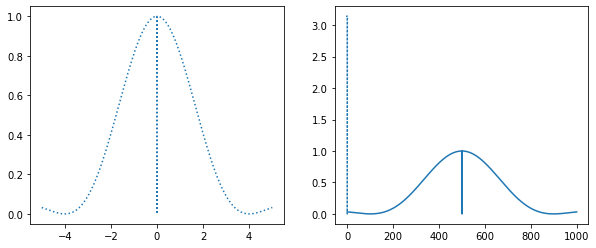

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
x1 = 1/(1j*omega*kk3)*(-1j)*A*kk3*np.pi * \
    T_h**2/(2*T)*np.sinc(kk3*T_h/(2*T))**2*w3
x1 = np.reshape(x1, (t.size, k3.size))
x1 = 1/T*np.sum(x1, axis=1)
x1 = np.real(x1)

x2 = 1/(1j*omega*kk4)*(-1j)*A*kk4*np.pi * \
    T_h**2/(2*T)*np.sinc(kk4*T_h/(2*T))**2*w4
x2 = np.reshape(x2, (t.size, k4.size))
x2 = 1/T*np.sum(x2, axis=1)
x2 = np.real(x2)

x = x1+x2


ax.set_xlabel('$t$')

ax.grid(True)
ax.set_xticks(np.arange(start=-2*T, stop=2*T+1/2*T, step=1/2*T))
ax.set_xlim(-2*T, 2*T)
ax.set_yticks(np.arange(-A, A+A, A))
# ax.set_ylim(-6/5*A,6/5*A)
# ax.set_yticklabels(['$0$',r'$\frac{A}{2}$','$A$'])
ax.plot(t, x, color='C0', clip_on=False, label='x_m(t)')
ax.legend()
fig.tight_layout()
fig.savefig('FB93908026_timedomain_15.pdf')
fig.clf()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))


k5 = np.arange(kmin, 0, 1/100)
ck = 1/(1j*omega*k5)*(-1j)*A*k5*np.pi*T_h**2/(2*T)*np.sinc(k5*T_h/(2*T))**2
ck = np.append(ck, np.array([0]))
k5 = np.arange(1/100, kmax+1/100, 1/100)
ck = np.append(ck, 1/(1j*omega*k5)*(-1j)*A*k5*np.pi *
               T_h**2/(2*T)*np.sinc(k5*T_h/(2*T))**2)
ax1.plot(k2, np.abs(ck), color='C0', ls=':')
ax2.plot(k2, np.angle(ck), color='C0', ls=':')
plt.plot(np.abs(ck))
plt.show()

ck = 1/(1j*omega*k3)*(-1j)*A*k3*np.pi*T_h**2/(2*T)*np.sinc(k3*T_h/(2*T))**2
ck = np.append(ck, np.array([0]))
ck = np.append(ck, 1/(1j*omega*k4)*(-1j)*A*k4*np.pi *
               T_h**2/(2*T)*np.sinc(k4*T_h/(2*T))**2)
ax1.plot(k, np.abs(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label='$|c_k|$')
ax2.plot(k, np.angle(ck), ls='', marker='o', mec='C1',
         mfc='C1', clip_on=False, label=r'$\varphi(c_k)$')

ax1.legend()
ax2.legend()
ax1.set_xlabel('$k$')
ax2.set_xlabel('$k$')
ax1.set_ylabel('$|c_k|$')
ax2.set_ylabel('$\\varphi(k)$')

ax1.set_yticks(np.arange(0, A*T_h+A*T_h/2, A*T_h/2))
#ax1.set_yticklabels(['$0$', r'$\frac{AT_h}{2}$','$AT_h$'])

ax2.set_yticks(np.arange(-np.pi, np.pi+np.pi/2, np.pi/2))
ax2.set_yticklabels(
    ['$-\pi$', r'$-\frac{\pi}{2}$', '$0$', r'$+\frac{\pi}{2}$', '$+\pi$'])

ax1.set_xticks(np.arange(kmin, kmax+1, 1))
ax2.set_xticks(np.arange(kmin, kmax+1, 1))

ax1.set_xlim(kmin, kmax)
ax2.set_xlim(kmin, kmax)

ax1.set_ylim(0, A*T_h)
ax2.set_ylim(-np.pi, np.pi)

ax1.set_title('Magnitude')
ax2.set_title('Phase')
ax1.grid(True)
ax2.grid(True)

fig.tight_layout()
fig.savefig('FB93908026_frequence_14.pdf')
fig.clf()
plt.close('all')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``main file, github URL, commit number and/or version tag, year``.